# Dataset -> UKP Essay Argument Annotated Corpus

### Benefit: Argument component detection

### Combining the .txt and .ann files into a single dataframe to make a meaningful dataset.

In [7]:
import os
import pandas as pd

DATA_PATH = "../data/ukp_essays"

records = []

for file in os.listdir(DATA_PATH):

    if file.endswith(".ann"):

        essay_id = file.replace(".ann", "")

        txt_path = os.path.join(DATA_PATH, essay_id + ".txt")
        ann_path = os.path.join(DATA_PATH, file)

        with open(txt_path, "r", encoding="utf-8") as f:
            essay_text = f.read()

        topic = essay_text.split("\n")[0]   # first line is topic

        with open(ann_path, "r", encoding="utf-8") as f:
            annotations = f.readlines()

        for line in annotations:

            if line.startswith("T"):

                parts = line.strip().split("\t")

                component_id = parts[0]
                type_span = parts[1]
                text = parts[2]

                component_type = type_span.split()[0]

                records.append({
                    "essay_id": essay_id,
                    "topic": topic,
                    "component_id": component_id,
                    "component_type": component_type,
                    "text": text
                })

df = pd.DataFrame(records)

### Converting the dataframe into csv for easier analysis

In [8]:
df.to_csv("ukp_argument_components.csv", index=False)

In [15]:
import pandas as pd

df = pd.read_csv("ukp_argument_components.csv")

df.head(20)

,essay_id,topic,component_id,component_type,text
0,essay01,Should students be taught to compete or to coo...,T1,Claim,competition can effectively promote the develo...
1,essay01,Should students be taught to compete or to coo...,T2,MajorClaim,we should attach more importance to cooperation
2,essay01,Should students be taught to compete or to coo...,T3,Premise,"In order to survive in the competition, compan..."
3,essay01,Should students be taught to compete or to coo...,T4,Claim,"through cooperation, children can learn about ..."
4,essay01,Should students be taught to compete or to coo...,T5,Premise,What we acquired from team work is not only ho...
5,essay01,Should students be taught to compete or to coo...,T6,Premise,"During the process of cooperation, children ca..."
6,essay01,Should students be taught to compete or to coo...,T7,Premise,All of these skills help them to get on well w...
7,essay01,Should students be taught to compete or to coo...,T8,Claim,competition makes the society more effective
8,essay01,Should students be taught to compete or to coo...,T9,Premise,the significance of competition is that how to...
9,essay01,Should students be taught to compete or to coo...,T10,Premise,when we consider about the question that how t...


In [19]:
## Shape of dataset 
df.shape

(1552, 5)

### The dataset has 1552 rows and 5 columns

In [20]:
## info of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1552 entries, 0 to 1551
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   essay_id        1552 non-null   object
 1   topic           1552 non-null   object
 2   component_id    1552 non-null   object
 3   component_type  1552 non-null   object
 4   text            1552 non-null   object
dtypes: object(5)
memory usage: 60.8+ KB


### Inference: All coumns are of object datatype.

In [21]:
## Columns of dataset
df.columns

Index(['essay_id', 'topic', 'component_id', 'component_type', 'text'], dtype='object')

### The dataset has 5 columns named:
- essay_id -> Contains the id of the essay.
- topic -> Contains the essay topic.
- component_id -> Contains id of the components in the essay.
- component_type -> Contains type of components in the essay namely: Claim, Major Claim, Premise.
- text -> Contains text of the component.

In [24]:
print(f"Total essay ids: {df['essay_id'].nunique()}")
print(f"Total essay topics: {df['topic'].nunique()}")

Total essay ids: 90
Total essay topics: 89


In [30]:
## getting topic which got repeated with different essay_id
df.groupby("topic")["essay_id"].nunique().sort_values(ascending=False).head()

topic
International tourism is now more common than ever before    2
Advertisements affects on consumer goods                     1
capital punishment..necessary or not                         1
Young people should go to university or not                  1
Will newspapers become a thing of the past?                  1
Name: essay_id, dtype: int64

**Inference:**

The dataset consists of **90 essays on 89 unique topics**, which implies that almost every essay is on a different topic. There is only **one topic that appears in two different essays**: "International tourism is now more common than ever before."

In [31]:
## Missing values check
df.isnull().sum()

essay_id          0
topic             0
component_id      0
component_type    0
text              0
dtype: int64

### Inference:

The dataset has no null datapoints.

## Distribution of Argument Components

In [32]:
df["component_type"].value_counts()

component_type
Premise       1033
Claim          429
MajorClaim      90
Name: count, dtype: int64

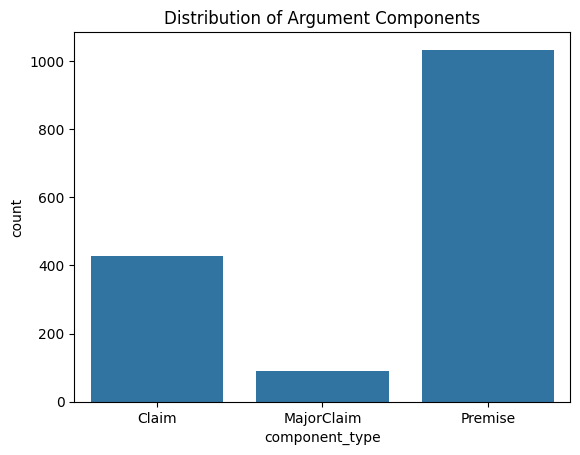

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="component_type")
plt.title("Distribution of Argument Components")
plt.show()

### Inference:

Premises dominate the dataset, indicating essays rely heavily on supporting evidence for claims.

## Argument Components per Essay

In [34]:
df.groupby("essay_id")["component_type"].count().describe()

count    90.000000
mean     17.244444
std       7.137984
min       8.000000
25%      13.250000
50%      16.000000
75%      18.750000
max      57.000000
Name: component_type, dtype: float64

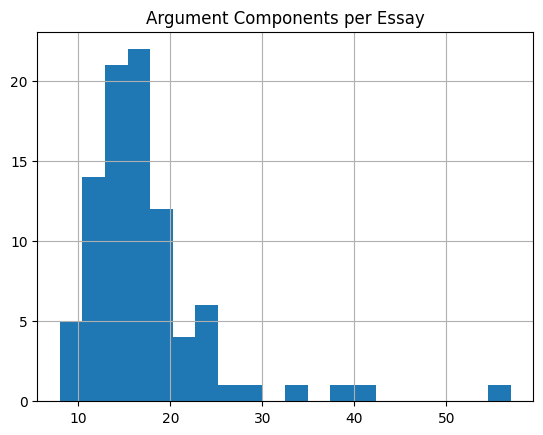

In [35]:
df.groupby("essay_id").size().hist(bins=20)
plt.title("Argument Components per Essay")
plt.show()

**Inference:**

The essays, on average, contain **~17 argument components**. Most essays contain anywhere from **13** to **19** argument components. There is a small degree of variability, with a few essays having many more argument components, up to **57**.

## Topic Distribution

In [36]:
df["topic"].value_counts().head(10)

topic
Everyone Should Go Camping                                         57
Why you should Exercise                                            42
The Non-Issue of Same Sex Marriage                                 38
Locker Checks                                                      34
The Truth About Cannabis                                           30
competition or co-operation-which is better                        26
is a break good or bad after high school for students              25
computers..use,future prospects and over-dependence                25
should universities accept equal number of males/females or not    25
Use of CCTV cameras                                                24
Name: count, dtype: int64

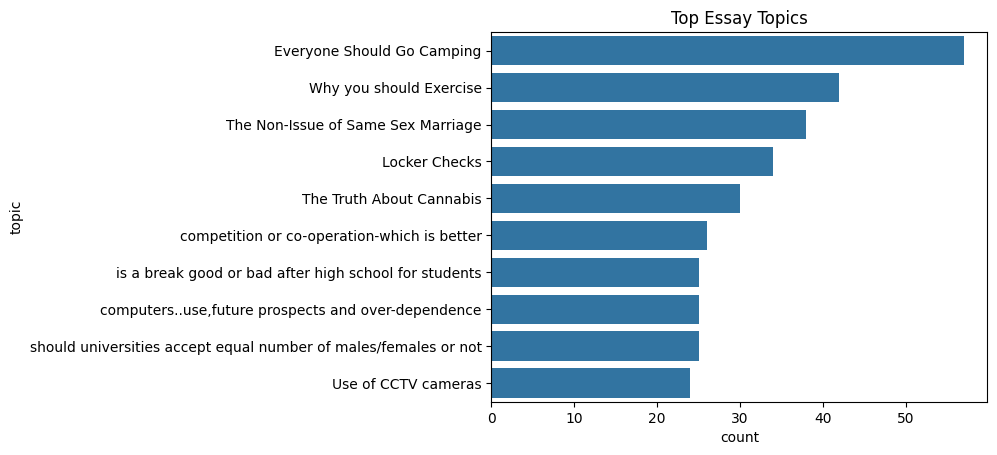

In [37]:
sns.countplot(
    y=df["topic"],
    order=df["topic"].value_counts().index[:10]
)

plt.title("Top Essay Topics")
plt.show()

**Inference:**

The range of arguments is wide as the dataset includes a variety of argumentative writing prompts. The most common arguments are related to **“Everyone Should Go Camping”** and **“Why you should Exercise”**. However, it is observed that the distribution is balanced, which shows that various debate topics are covered in the essays.

## Text Length Analysis

In [38]:
### Character length
df["char_length"] = df["text"].apply(len)

df["char_length"].describe()

count    1552.000000
mean       90.246778
std        41.007339
min        15.000000
25%        59.000000
50%        84.000000
75%       112.000000
max       297.000000
Name: char_length, dtype: float64

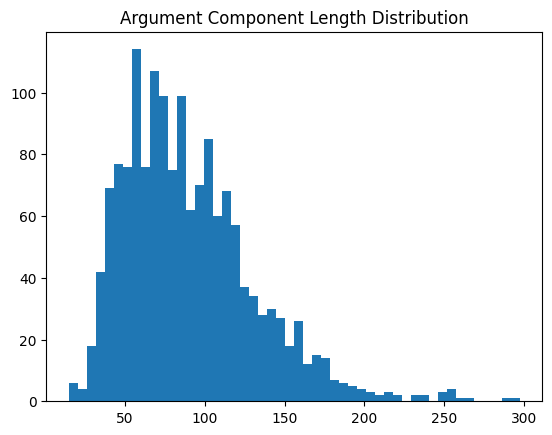

In [39]:
plt.hist(df["char_length"], bins=50)
plt.title("Argument Component Length Distribution")
plt.show()

**Inference:**

Argument components in the dataset are relatively short, with an average length of **~90 characters**. Most components fall between **59 and 112 characters**, while a few longer components extend up to **~297 characters**, indicating that the dataset primarily consists of concise argumentative statements with occasional detailed explanations.


In [40]:
### Word length
df["word_count"] = df["text"].apply(lambda x: len(x.split()))

df["word_count"].describe()

count    1552.000000
mean       14.933634
std         6.751467
min         2.000000
25%        10.000000
50%        14.000000
75%        19.000000
max        58.000000
Name: word_count, dtype: float64

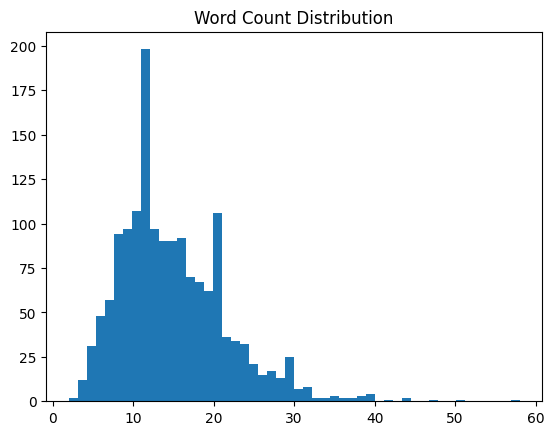

In [41]:
plt.hist(df["word_count"], bins=50)
plt.title("Word Count Distribution")
plt.show()

### Inference:

Argument components are relatively short text spans, making them suitable for sequence classification models.

## Component Length by Type

c:\Users\hp\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


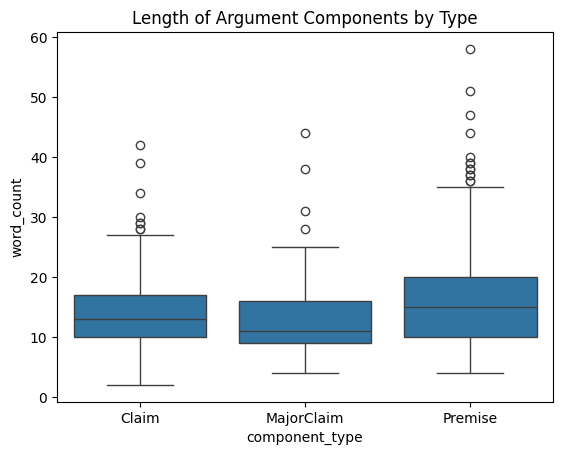

In [42]:
sns.boxplot(
    data=df,
    x="component_type",
    y="word_count"
)

plt.title("Length of Argument Components by Type")
plt.show()

**Inference:**

Premises tend to be **longer and more variable** than claims and major claims, as they typically provide detailed supporting evidence. In contrast, **claims and major claims are shorter and more concise**, reflecting their role in stating the main argumentative positions rather than elaborating on them.


## Vocabulary Analysis

In [43]:
from collections import Counter

all_words = " ".join(df["text"]).split()

vocab = Counter(all_words)

print("Vocabulary size:", len(vocab))
print(vocab.most_common(20))

Vocabulary size: 4334
[('the', 1202), ('to', 826), ('of', 729), ('and', 677), ('a', 476), ('in', 465), ('is', 356), ('are', 270), ('be', 260), ('for', 240), ('their', 224), ('can', 222), ('it', 171), ('they', 170), ('people', 167), ('as', 154), ('more', 153), ('not', 150), ('have', 149), ('that', 142)]


In [44]:
## Clean vocabulary
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

clean_words = [
    w for w in all_words
    if w.lower() not in stop_words and w.isalpha()
]

print("Clean vocab size:", len(set(clean_words)))

Clean vocab size: 3496


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Inference:**

The dataset contains a vocabulary of **~4.3K unique words**, which reduces to **~3.5K meaningful tokens after removing stopwords**, indicating a moderately rich and diverse linguistic space suitable for training argument mining models.


## Argument Structure Patterns

In [45]:
df.groupby(["essay_id", "component_type"]).size().unstack().fillna(0)

component_type,Claim,MajorClaim,Premise
essay_id,,,
essay01,5,1,8
essay02,5,1,8
essay03,6,1,5
essay04,6,1,4
essay05,4,1,7
...,...,...,...
essay86,4,1,4
essay87,6,1,11
essay88,4,1,17


**Inference:**

Most essays contain one major claim supported by multiple claims and premises.

## Longest and Shortest Components

In [46]:
df.sort_values("word_count", ascending=False).head()

,essay_id,topic,component_id,component_type,text,char_length,word_count
10,essay01,Should students be taught to compete or to coo...,T11,Premise,Take Olympic games which is a form of competit...,297,58
1106,essay63,people will spend less time on cooking food,T9,Premise,"According to a recent survey, 89% of people ha...",267,51
744,essay42,Paying more money is the only motivation to ma...,T3,Premise,junior high school teachers have great respons...,263,47
1250,essay72,Those who use drugs should be automatically se...,T17,MajorClaim,sending the drug addicts to rehabilitation cen...,253,44
43,essay04,International tourism is now more common than ...,T4,Premise,"Take Thailand for example, in the Vietnam War,...",286,44


In [47]:
df.sort_values("word_count").head()

,essay_id,topic,component_id,component_type,text,char_length,word_count
292,essay12,Locker Checks,T32,Claim,Students should,15,2
91,essay06,Why you should Exercise,T29,Claim,it's really fun,15,3
566,essay31,Alternative forms of transport to alleviate tr...,T9,Premise,traffic congestion irritates drivers,36,4
322,essay14,Lessons with teachers versus others sources,T14,Premise,stundents learn things easily,29,4
185,essay10,The Non-Issue of Same Sex Marriage,T20,Premise,it is no different,18,4


**Inference:**

Premises often contain detailed explanations, making them the longest components.

## Example Components

In [48]:
for i in range(5):
    print(df["component_type"].iloc[i])
    print(df["text"].iloc[i])
    print()

Claim
competition can effectively promote the development of economy

MajorClaim
we should attach more importance to cooperation

Premise
In order to survive in the competition, companies continue to improve their products and service, and as a result, the whole society prospers

Claim
through cooperation, children can learn about interpersonal skills which are significant in the future life of all students

Premise
What we acquired from team work is not only how to achieve the same goal with others but more importantly, how to get along with others



# Key Insights

- The dataset contains 90 essays and 89 unique prompts.

- Premises dominate the dataset, highlighting the importance of supporting evidence in argumentative essays.

- Each essay typically contains one major claim supported by multiple claims and premises.

- Argument components are short text spans, making them suitable for classification using transformer-based models.

- The dataset contains a rich vocabulary and diverse essay topics.